# Classification Modelleri

## Gerekli Kütüphaneler

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
from datetime import timedelta
import scipy.stats as stats
import warnings
import math

In [2]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score

## Problem: Bank Marketing

Bank Marketing verisi, Portekiz’de bir bankanın telefon kampanyası sonuçlarını içeriyor. Amaç müşterinin mevduat (term deposit) açıp açmayacağını tahmin etmek.

- Dataset: https://archive.ics.uci.edu/dataset/222/bank+marketing
- Makale: https://www.semanticscholar.org/paper/A-data-driven-approach-to-predict-the-success-of-Moro-Cortez/cab86052882d126d43f72108c6cb41b295cc8a9e

#### Input variables:
    
    bank client data:
   1. age (numeric)
   2. job : type of job (categorical: "admin.","blue-collar","entrepreneur","housemaid","management","retired","self-employed","services","student","technician","unemployed","unknown")
   3. marital : marital status (categorical: "divorced","married","single","unknown"; note: "divorced" means divorced or widowed)
   4. education (categorical: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown")
   5. default: has credit in default? (categorical: "no","yes","unknown")
   6. housing: has housing loan? (categorical: "no","yes","unknown")
   7. loan: has personal loan? (categorical: "no","yes","unknown")
    
    related with the last contact of the current campaign:
   8. contact: contact communication type (categorical: "cellular","telephone") 
   9. month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  10. day_of_week: last contact day of the week (categorical: "mon","tue","wed","thu","fri")
  11. duration: last contact duration, in seconds (numeric). Important note:  this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    
    other attributes:
  12. campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
  13. pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
  14. previous: number of contacts performed before this campaign and for this client (numeric)
  15. poutcome: outcome of the previous marketing campaign (categorical: "failure","nonexistent","success")
    
    social and economic context attributes
  16. emp.var.rate: employment variation rate - quarterly indicator (numeric)
  17. cons.price.idx: consumer price index - monthly indicator (numeric)     
  18. cons.conf.idx: consumer confidence index - monthly indicator (numeric)     
  19. euribor3m: euribor 3 month rate - daily indicator (numeric)
  20. nr.employed: number of employees - quarterly indicator (numeric)

    Output variable (desired target):
  21. y - has the client subscribed a term deposit? (binary: "yes","no")

## EDA

In [3]:
df_bank = pd.read_csv('bank-additional-full.csv', sep=';')

In [4]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [75]:
df_bank.y = df_bank.y.replace({"yes": 1, "no": 0})

In [76]:
df_bank.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [6]:
X = df_bank.drop("y", axis = 1)
y = df_bank.y

In [68]:
y.value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

In [71]:
len(y[y==1]) / len(y)

0.11265417111780131

In [7]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [8]:
categoric_cols = X.select_dtypes(include='object').columns.tolist()

In [78]:
df_bank[numeric_cols + ['y']].corr()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725,0.030399
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703,0.405274
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095,-0.066357
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605,-0.324914
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333,0.230181
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970,-0.298334
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034,-0.136211
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513,0.054878
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154,-0.307771
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000,-0.354678


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>],
       [<Axes: title={'center': 'pdays'}>,
        <Axes: title={'center': 'previous'}>,
        <Axes: title={'center': 'emp.var.rate'}>],
       [<Axes: title={'center': 'cons.price.idx'}>,
        <Axes: title={'center': 'cons.conf.idx'}>,
        <Axes: title={'center': 'euribor3m'}>],
       [<Axes: title={'center': 'nr.employed'}>, <Axes: >, <Axes: >]],
      dtype=object)

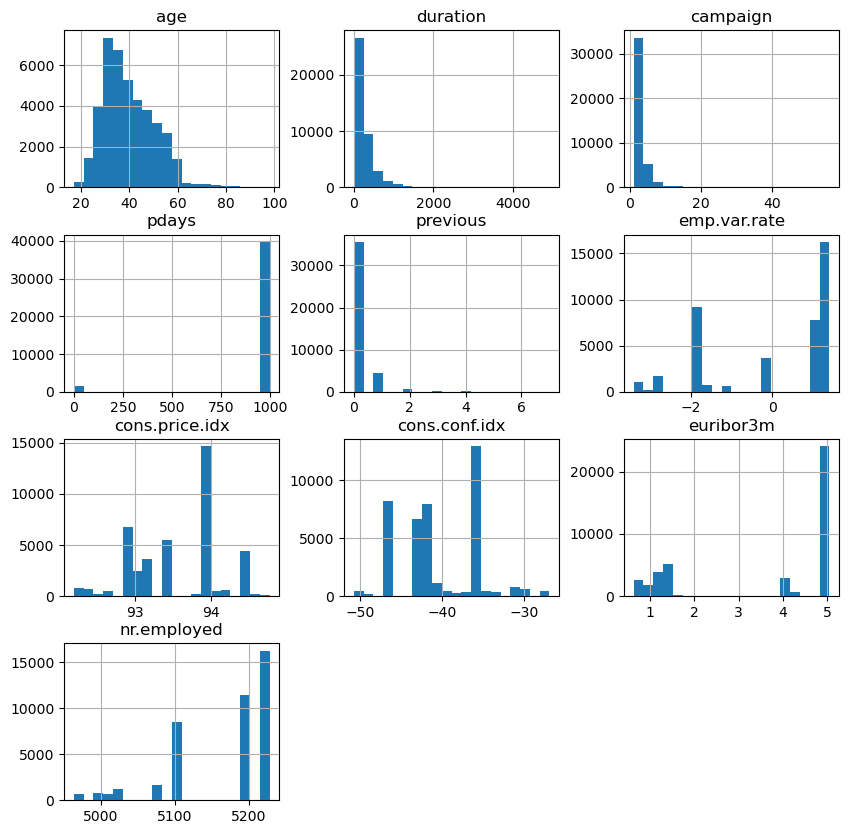

In [12]:
X[numeric_cols].hist(bins = 20, figsize = (10,10))

In [14]:
for c in categoric_cols:
    X[c] = X[c].astype("category")

In [14]:
np.sum(y == 1) / len(y)

0.11265417111780131

In [24]:
for c in categoric_cols:
    
    print(df_bank.groupby(c).count()[["y"]].sort_values("y", ascending = False))
    print("-----------------------")

                   y
job                 
admin.         10422
blue-collar     9254
technician      6743
services        3969
management      2924
retired         1720
entrepreneur    1456
self-employed   1421
housemaid       1060
unemployed      1014
student          875
unknown          330
-----------------------
              y
marital        
married   24928
single    11568
divorced   4612
unknown      80
-----------------------
                         y
education                 
university.degree    12168
high.school           9515
basic.9y              6045
professional.course   5243
basic.4y              4176
basic.6y              2292
unknown               1731
illiterate              18
-----------------------
             y
default       
no       32588
unknown   8597
yes          3
-----------------------
             y
housing       
yes      21576
no       18622
unknown    990
-----------------------
             y
loan          
no       33950
yes       6248
unknown   

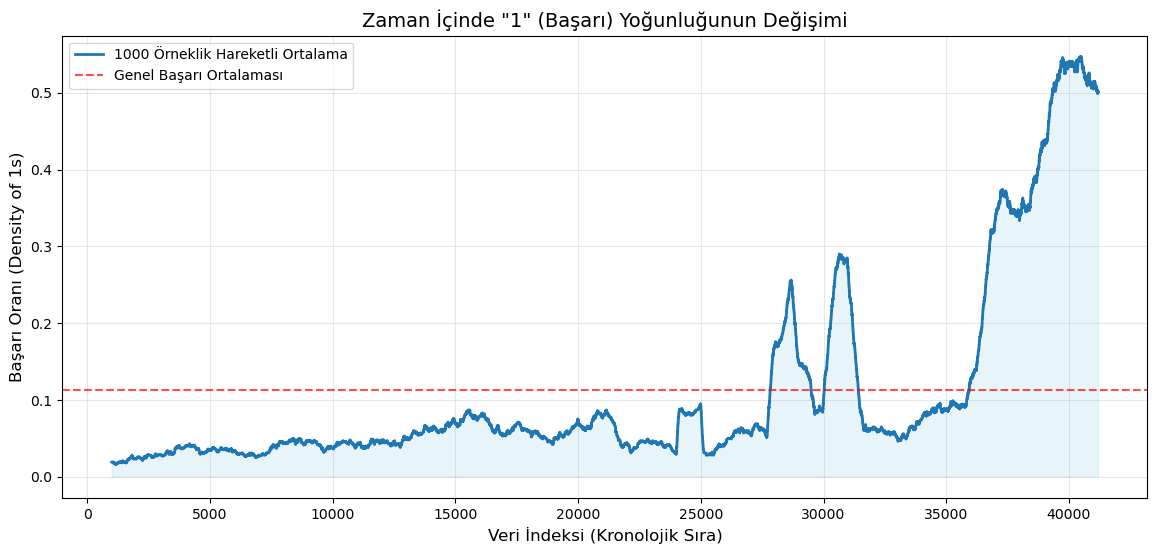

In [120]:
window_size = 1000 
df_bank['rolling_success_rate'] = df_bank['y'].rolling(window=window_size).mean()

plt.figure(figsize=(14, 6))

plt.plot(df_bank.index, df_bank['rolling_success_rate'], color='#1f77b4', linewidth=2, label=f'{window_size} Örneklik Hareketli Ortalama')

plt.axhline(y=df_bank['y'].mean(), color='red', linestyle='--', alpha=0.7, label='Genel Başarı Ortalaması')

plt.title('Zaman İçinde "1" (Başarı) Yoğunluğunun Değişimi', fontsize=14)
plt.xlabel('Veri İndeksi (Kronolojik Sıra)', fontsize=12)
plt.ylabel('Başarı Oranı (Density of 1s)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.fill_between(df_bank.index, df_bank['rolling_success_rate'], color='skyblue', alpha=0.2)

plt.show()

## Modelling

### Cross Validation

Cross Validation (Çapraz Doğrulama), modelin performansını ölçerken "şans faktörünü" ortadan kaldırmak için kullanılan bir yöntemdir.

#### Time Series Split:

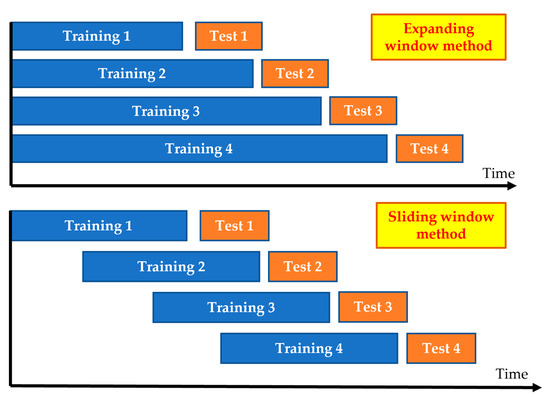

In [84]:
tscv = TimeSeriesSplit(n_splits=4)

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X, y)):
    X_tr, X_te  = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te  = y.iloc[tr_idx], y.iloc[te_idx]
    
    print(f"Fold {fold}:")
    print(f"Train size: {len(y_tr)}, class ratio: {round(np.sum(y_tr == 1) / len(y_tr), 3)}")
    print(f"Test size: {len(y_te)},  class ratio: {round(np.sum(y_te == 1) / len(y_te), 3)}")

Fold 0:
Train size: 8240, class ratio: 0.031
Test size: 8237,  class ratio: 0.054
Fold 1:
Train size: 16477, class ratio: 0.043
Test size: 8237,  class ratio: 0.059
Fold 2:
Train size: 24714, class ratio: 0.048
Test size: 8237,  class ratio: 0.111
Fold 3:
Train size: 32951, class ratio: 0.064
Test size: 8237,  class ratio: 0.308


In [89]:
tscv = TimeSeriesSplit(n_splits=4, max_train_size = 10000)

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X, y)):
    X_tr, X_te  = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te  = y.iloc[tr_idx], y.iloc[te_idx]
    
    print(f"Fold {fold}:")
    print(f"Train size: {len(y_tr)}, class ratio: {round(np.sum(y_tr == 1) / len(y_tr), 3)}")
    print(f"Test size: {len(y_te)},  class ratio: {round(np.sum(y_te == 1) / len(y_te), 3)}")

Fold 0:
Train size: 8240, class ratio: 0.031
Test size: 8237,  class ratio: 0.054
Fold 1:
Train size: 10000, class ratio: 0.052
Test size: 8237,  class ratio: 0.059
Fold 2:
Train size: 10000, class ratio: 0.061
Test size: 8237,  class ratio: 0.111
Fold 3:
Train size: 10000, class ratio: 0.102
Test size: 8237,  class ratio: 0.308


### Model Evaluation

#### AUC (ROC AUC — Area Under the ROC Curve):
    
Ayırt Etme Gücü: Modelin pozitif ve negatif sınıfları birbirinden ne kadar iyi ayrıştırdığının ölçüsüdür. (Baz değer 0.5, yani rastgele tahmindir).

Threshold Bağımsızlığı: Accuracy veya F1 Score gibi metriklerin aksine, belirli bir eşik değerine (threshold) ihtiyaç duymaz.

Sıralama (Ranking) Odaklı: Modelin ürettiği olasılık değerlerinin mutlak büyüklüğüne değil, sıralamasına bakar. Pozitif örneğe negatiften daha yüksek puan verip vermediğini ölçer.

Kullanım Alanı: Özellikle dengesiz veri setlerinde ve en uygun threshold değerinin henüz belirlenmediği aşamalarda modelin genel performansını görmek için idealdir.

#### F1 Score:

Precision (kesinlik) ve Recall (duyarlılık) arasında denge kuran harmonik ortalamadır. Özellikle imbalance verisetleri için accuracy ve AUC score’a göre çok daha uygundur.

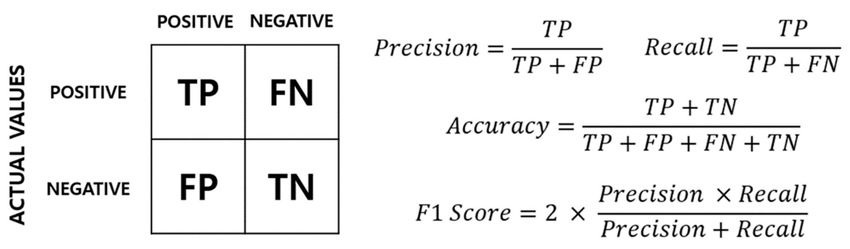

#### Precision @ k, Recall @ k, Lift @ k:

Precision @ k (İlk k'da Kesinlik): Modelin en yüksek skorla önerdiği ilk k sonucun (örn. ilk 10 ürün) ne kadarının isabetli olduğunu gösterir. Kullanıcının önüne düşen listenin "ne kadar temiz ve doğru" olduğuyla ilgilenir.

Recall @ k (İlk k'da Kapsama): Veri setinde var olan tüm pozitif/ilgili öğelerin ne kadarının, modelin sunduğu ilk k sonuç arasına girebildiğini ölçer. Sistemin, kullanıcının ilgisini çekebilecek tüm seçenekleri listenin en başına taşıyıp taşıyamadığını gösterir.

Lift @ k (İlk k'da Kaldıraç): Modelin seçtiği ilk k gruptaki başarı oranının, veri setindeki genel ortalamaya (rastgele seçime) göre kaç kat daha yüksek olduğunu ifade eder. Modelin, en değerli örnekleri listenin en tepesine yığma (ranking) becerisini kanıtlar.

In [30]:
def precision_recall_lift_at_k(y_true, y_score, percentage=0.1):

    y_true = np.array(y_true)
    y_score = np.array(y_score)
    
    n = len(y_true)
    k = int(n * percentage)
    
    idx = np.argsort(-y_score)
    topk_idx = idx[:k]
    
    # precision@k
    precision_at_k = y_true[topk_idx].sum() / k
    
    # recall@k
    recall_at_k = y_true[topk_idx].sum() / y_true.sum()
    
    # base rate
    base_rate = y_true.mean()
    
    # lift@k
    lift_at_k = precision_at_k / base_rate if base_rate > 0 else np.nan
    
    return {
        "precision_at_k": round(precision_at_k, 3),
        "recall_at_k": round(recall_at_k, 3),
        "lift_at_k": round(lift_at_k, 3)
    }

In [135]:
def cv_model_training(X, y, params, n_splits=4, random_state=42, eval_metric='auc', max_train_size=None):
    aucs, precision_recall_lift_metrics = [], []
    all_y, all_y_probs = [], []
    
    tscv = TimeSeriesSplit(n_splits=n_splits, max_train_size=max_train_size)

    for tr_idx, te_idx in tscv.split(X, y):
        X_tr, X_test = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_test = y.iloc[tr_idx], y.iloc[te_idx]

        X_tr, X_val, y_tr, y_val = train_test_split(
            X_tr, y_tr, test_size=0.2, shuffle=False
        )
        
        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric=eval_metric,
            callbacks=[
                lgb.early_stopping(stopping_rounds=50), 
                lgb.log_evaluation(period=0)
            ]
        )

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        aucs.append(roc_auc_score(y_test, y_prob))        
        precision_recall_lift_metrics.append(precision_recall_lift_at_k(y_test, y_prob))
        
        all_y.extend(y_test)
        all_y_probs.extend(y_prob)

    print("\n" + "="*30)
    print(f"{'Fold':<6} | {'AUC':<10}")
    print("-" * 30)

    for i in range(len(aucs)):
        print(f"{i+1:<6} | {aucs[i]:<10.4f}")

    print("-" * 30)
    print(f"{'MEAN':<6} | {np.mean(aucs):<10.4f}")
    print("="*30)

    print("\n[Precision-Recall Lift Metrics]")
    for i, m in enumerate(precision_recall_lift_metrics):
        print(f"Fold {i+1}: Precision@K: {m['precision_at_k']:.3f}, Recall@K: {m['recall_at_k']:.3f}, Lift: {m['lift_at_k']:.3f}")
    print("="*30 + "\n")

    return np.array(all_y), np.array(all_y_probs)

In [122]:
params_default = {
 'learning_rate': 0.05,
 'num_leaves': 100,
 'lambda_l2': 1.0,
 'max_depth': 10,
 'verbosity': -1,
 'seed': 42}

In [123]:
y_test, y_prob = cv_model_training(X, y, params_default, eval_metric = "auc") #expanding

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[4]	valid_0's auc: 0.953816	valid_0's binary_logloss: 0.137573
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[99]	valid_0's auc: 0.954503	valid_0's binary_logloss: 0.125664
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[35]	valid_0's auc: 0.885471	valid_0's binary_logloss: 0.146775
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[17]	valid_0's auc: 0.749182	valid_0's binary_logloss: 0.381613

Fold   | AUC       
------------------------------
1      | 0.9571    
2      | 0.9108    
3      | 0.7825    
4      | 0.6953    
------------------------------
MEAN   | 0.8364    

[Precision-Recall Lift Metrics]
Fold 1: Precision@K: 0.443, Recall@K: 0.817, Lift: 8.172
Fold 2: Precision@K: 0.428, Recall@K: 0.730, Lift: 7.309
Fold 3: Precision@

In [136]:
y_test, y_prob = cv_model_training(X, y, params_default, eval_metric = "auc", max_train_size = 10000) #sliding

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[4]	valid_0's auc: 0.953816	valid_0's binary_logloss: 0.137573
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[25]	valid_0's auc: 0.953479	valid_0's binary_logloss: 0.144925
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[20]	valid_0's auc: 0.767936	valid_0's binary_logloss: 0.186351
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[31]	valid_0's auc: 0.960621	valid_0's binary_logloss: 0.144435

Fold   | AUC       
------------------------------
1      | 0.9571    
2      | 0.9111    
3      | 0.7692    
4      | 0.8000    
------------------------------
MEAN   | 0.8593    

[Precision-Recall Lift Metrics]
Fold 1: Precision@K: 0.443, Recall@K: 0.817, Lift: 8.172
Fold 2: Precision@K: 0.429, Recall@K: 0.732, Lift: 7.330
Fold 3: Precision@K: 0.448, Rec

In [131]:
def get_lift_table(y_true, y_probs, steps=[0.05, 0.1, 0.2, 0.3, 0.4, 0.5]):

    df = pd.DataFrame({'y_true': y_true, 'y_prob': y_prob}).sort_values('y_prob', ascending=False)
    total_positives = df['y_true'].sum()
    
    results = {}
    for step in steps:

        top_n = int(len(df) * step)
        captured_positives = df['y_true'].head(top_n).sum()
        results[f"{int(step*100)}%"] = f"{(captured_positives / total_positives) * 100:.1f}%"
        
    return results

In [138]:
lift_results = get_lift_table(y_test, y_prob)

In [139]:
lift_results

{'5%': '22.5%',
 '10%': '42.0%',
 '20%': '70.9%',
 '30%': '85.6%',
 '40%': '91.9%',
 '50%': '92.4%'}